# Graph Conversions: GraKeL ↔ NetworkX

This tutorial shows how to convert graphs between GraKeL and NetworkX formats using `networkx_from_graph` and `graph_from_networkx`, and validates that a full round-trip preserves the graph structure and its labels.

We use the **PTC-FM** benchmark dataset from the TU Dortmund collection, whose graphs are undirected and carry both node labels (atom types) and edge labels (bond types).

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

from grakel import graph_from_networkx
from grakel import networkx_from_graph
from grakel.datasets import fetch_dataset

## 1. Loading a benchmark dataset

We load **PTC-FM** with `fetch_dataset`. The `as_graphs=True` option returns the data directly as a list of `grakel.Graph` objects.

In [2]:
ptc_fm = fetch_dataset("PTC_FM", verbose=False, as_graphs=True)
graphs = ptc_fm.data

# pick the largest graph for a clearer visual comparison
g0 = graphs[2]
print("Number of graphs in PTC_FM:", len(graphs))
print("Sample node labels:", dict(list(g0.node_labels.items())[:6]))
print("Sample edge labels:", dict(list(g0.edge_labels.items())[:6]))

Number of graphs in PTC_FM: 349
Sample node labels: {53: 2, 54: 2, 55: 3, 56: 2, 57: 2, 58: 3}
Sample edge labels: {(54, 53): 3, (53, 54): 3, (55, 54): 1, (54, 55): 1, (56, 54): 3, (54, 56): 3}


## 2. GraKeL → NetworkX

`networkx_from_graph` converts a `grakel.Graph` into a `networkx.Graph`. Node and edge labels are attached as node/edge attributes under the tag given by `node_labels_tag` / `edge_labels_tag`. PTC-FM is unweighted, so we pass `edge_weight_tag=None` to avoid adding spurious `weight` attributes.

In [3]:
netG = networkx_from_graph(g0,
                           node_labels_tag='label',
                           edge_labels_tag='label',
                           edge_weight_tag=None,
                           directed=False)

print(netG)
print()
print("Node attributes of the first 6 nodes:")
print(sorted(netG.nodes(data='label'))[:6])

Graph with 20 nodes and 22 edges

Node attributes of the first 6 nodes:
[(53, 2), (54, 2), (55, 3), (56, 2), (57, 2), (58, 3)]


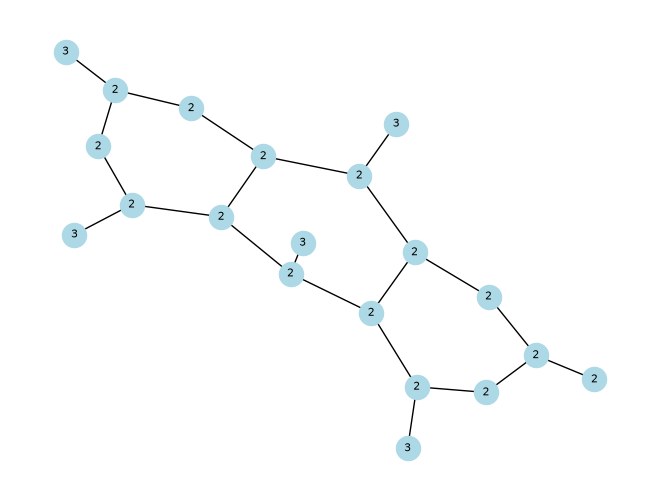

In [4]:
nx.draw(netG, with_labels=True, labels=nx.get_node_attributes(netG, 'label'), node_color='lightblue', font_size=8)

## 3. Comparing the two adjacency matrices

The two representations are displayed side by side and compared numerically. Note that `get_adjacency_matrix()` orders rows and columns by *sorted* vertex ids, so we align the NetworkX matrix with `nodelist=sorted(netG.nodes())`.

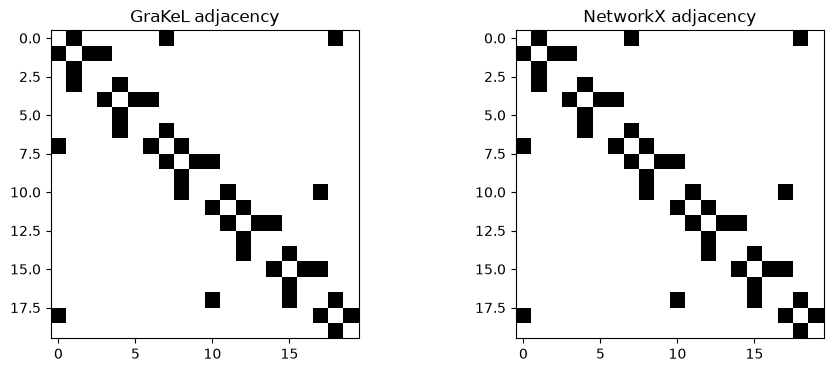

Adjacency matrices identical: True


In [5]:
A_grakel = g0.get_adjacency_matrix()
A_nx = nx.to_numpy_array(netG, nodelist=sorted(netG.nodes()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(A_grakel, cmap='Greys')
axes[0].set_title('GraKeL adjacency')
axes[1].imshow(A_nx, cmap='Greys')
axes[1].set_title('NetworkX adjacency')
plt.show()

print("Adjacency matrices identical:", np.array_equal(A_grakel, A_nx))

## 4. Round trip: NetworkX → GraKeL

We convert the NetworkX graph back into a `grakel.Graph` with `graph_from_networkx` (using `as_Graph=True` to obtain `Graph` objects) and check that the structure, node labels and edge labels are all preserved.

In [6]:
g_back = list(graph_from_networkx([netG],
                                  node_labels_tag='label',
                                  edge_labels_tag='label',
                                  edge_weight_tag=None,
                                  as_Graph=True))[0]

A_back = g_back.get_adjacency_matrix()

print("Structure preserved:   ", np.array_equal(A_grakel, A_back))
print("Node labels preserved: ", g_back.node_labels == g0.node_labels)
print("Edge labels preserved: ", g_back.edge_labels == g0.edge_labels)

Structure preserved:    True
Node labels preserved:  True
Edge labels preserved:  True


## 5. A directed example with custom weights and labels

For directed graphs pass `directed=True`. The example below uses asymmetric weights, so the direction of every edge is preserved through the round trip.

In [7]:
G_dir = nx.DiGraph()
G_dir.add_edge('a', 'b', weight=2.5, elabel='strong')
G_dir.add_edge('b', 'a', weight=0.7, elabel='weak')
G_dir.add_edge('b', 'c', weight=1.3, elabel='normal')
nx.set_node_attributes(G_dir, {'a': 'C', 'b': 'N', 'c': 'O'}, 'nlabel')

# NetworkX -> GraKeL
gk_dir = list(graph_from_networkx([G_dir],
                                  node_labels_tag='nlabel',
                                  edge_labels_tag='elabel',
                                  edge_weight_tag='weight',
                                  as_Graph=True))[0]

# GraKeL -> NetworkX
netG_back = networkx_from_graph(gk_dir,
                                node_labels_tag='nlabel',
                                edge_labels_tag='elabel',
                                edge_weight_tag='weight',
                                directed=True)

print("Directed:", netG_back.is_directed())
print("Node labels:", dict(netG_back.nodes(data='nlabel')))
print("Edges:")
for u, v, data in netG_back.edges(data=True):
    print(" ", u, "->", v, dict(data))

Directed: True
Node labels: {'c': 'O', 'b': 'N', 'a': 'C'}
Edges:
  b -> a {'weight': 0.7, 'elabel': 'weak'}
  b -> c {'weight': 1.3, 'elabel': 'normal'}
  a -> b {'weight': 2.5, 'elabel': 'strong'}
